# SoRL attention mask proof

This notebook proves that changing `memory_span_abs` / `memory_span_traj` changes the **actual propagation result** in `SorlModelWrapper`, not just the mask tensor.

It does this by:
1. Building a tiny random `SorlModelWrapper` from scratch.
2. Constructing a sequence with both NL and abstract tokens.
3. Building SoRL additive attention masks for different span settings.
4. Running the *same* model and *same* input under different masks.
5. Comparing logits and argmax predictions to show propagation changes.


In [7]:
import os
import sys
from pathlib import Path

import torch
from transformers import LlamaConfig

repo_root = Path.cwd()
if not (repo_root / 'sorl').exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from sorl.sorl_wrapper import SorlModelWrapper

torch.manual_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [2]:
cfg = LlamaConfig(
    vocab_size=64,
    hidden_size=64,
    intermediate_size=128,
    num_hidden_layers=2,
    num_attention_heads=4,
    num_key_value_heads=4,
    max_position_embeddings=128,
    pad_token_id=0,
    bos_token_id=1,
    eos_token_id=2,
)
wrapper = SorlModelWrapper.from_scratch(cfg, full_vocab_size_list=[64, 8], pad_token_id=0).to(device).eval()
base_vocab = int(wrapper.vocab_sizes[0].item())
total_vocab = int(wrapper.total_vocab_size.item())
base_vocab, total_vocab

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
The new lm_head weights will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


(64, 73)

We create a sequence with interleaved NL and abstract tokens.

- Base vocab tokens are `< 64>`
- Abstract tokens are `>= 65`
- `64` itself is the placeholder token, so we avoid it


In [3]:
ABS1 = base_vocab + 1
ABS2 = base_vocab + 2
ABS3 = base_vocab + 3

tokens = torch.tensor([[
    1,   11, 12, 13,
    ABS1,
    21, 22, 23, 24,
    ABS2,
    31, 32, 33, 34, 35,
    ABS3,
    41, 42, 43
]], dtype=torch.long, device=device)
attn = torch.ones_like(tokens, device=device)
tokens.shape, tokens.tolist()[0]

(torch.Size([1, 19]),
 [1, 11, 12, 13, 65, 21, 22, 23, 24, 66, 31, 32, 33, 34, 35, 67, 41, 42, 43])

In [4]:
def run_case(memory_span_abs, memory_span_traj):
    mask = wrapper._create_sorl_attention_mask(
        tokens, attn, memory_span_abs=memory_span_abs, memory_span_traj=memory_span_traj
    )
    with torch.no_grad():
        out = wrapper.model(input_ids=tokens, attention_mask=mask, use_cache=False)
    return mask, out.logits

mask_small_abs, logits_small_abs = run_case(memory_span_abs=1, memory_span_traj=128)
mask_large_abs, logits_large_abs = run_case(memory_span_abs=128, memory_span_traj=128)
mask_small_traj, logits_small_traj = run_case(memory_span_abs=128, memory_span_traj=1)
mask_large_traj, logits_large_traj = run_case(memory_span_abs=128, memory_span_traj=128)


In [9]:
def summarize_mask_diff(name_a, mask_a, name_b, mask_b):
    allowed_a = torch.isfinite(mask_a[0, 0]) & (mask_a[0, 0] == 0)
    allowed_b = torch.isfinite(mask_b[0, 0]) & (mask_b[0, 0] == 0)
    changed = (allowed_a != allowed_b)
    n_changed = int(changed.sum().item())
    print(f'{name_a} vs {name_b}: changed attention edges = {n_changed}')
    if n_changed > 0:
        idx = changed.nonzero()[:20].tolist()
        print('first changed (query_idx, key_idx):', idx)

# summarize_mask_diff('abs=1', mask_small_abs, 'abs=128', mask_large_abs)
# summarize_mask_diff('traj=1', mask_small_traj, 'traj=128', mask_large_traj)

In [11]:
def summarize_logit_diff(name_a, logits_a, name_b, logits_b):
    diff = (logits_a - logits_b).abs()
    max_diff = float(diff.max().item())
    mean_diff = float(diff.mean().item())
    argmax_changed_positions = int((logits_a.argmax(-1) != logits_b.argmax(-1)).sum().item())
    print(f'{name_a} vs {name_b}:')
    print(f'  max |logit diff| = {max_diff:.6f}')
    print(f'  mean |logit diff| = {mean_diff:.6f}')
    print(f'  argmax-changed positions = {argmax_changed_positions}')

# summarize_logit_diff('abs=1', logits_small_abs, 'abs=128', logits_large_abs)
# summarize_logit_diff('traj=1', logits_small_traj, 'traj=128', logits_large_traj)

If either comparison shows nonzero changed edges and nonzero logit differences, then the mask is not merely being constructed — it is changing the forward propagation result.


In [7]:
last_pos = -1
topk = 10

def top_tokens(logits, name):
    vals, idx = torch.topk(logits[0, last_pos], k=topk)
    print(name)
    for v, i in zip(vals.tolist(), idx.tolist()):
        print(f'  token={i:3d}  logit={v:.4f}')

top_tokens(logits_small_abs, 'Top logits at last position | abs=1')
top_tokens(logits_large_abs, 'Top logits at last position | abs=128')
top_tokens(logits_small_traj, 'Top logits at last position | traj=1')
top_tokens(logits_large_traj, 'Top logits at last position | traj=128')

Top logits at last position | abs=1
  token= 46  logit=0.2949
  token= 24  logit=0.2761
  token= 42  logit=0.2320
  token= 21  logit=0.2066
  token= 13  logit=0.1960
  token= 55  logit=0.1952
  token= 36  logit=0.1751
  token= 14  logit=0.1656
  token=  4  logit=0.1637
  token=  2  logit=0.1631
Top logits at last position | abs=128
  token= 46  logit=0.3027
  token= 24  logit=0.2900
  token= 21  logit=0.2327
  token= 13  logit=0.2015
  token= 42  logit=0.2007
  token= 55  logit=0.1937
  token= 35  logit=0.1543
  token=  4  logit=0.1538
  token=  2  logit=0.1472
  token= 14  logit=0.1366
Top logits at last position | traj=1
  token= 24  logit=0.2767
  token= 46  logit=0.2485
  token= 13  logit=0.2145
  token= 21  logit=0.1952
  token= 56  logit=0.1817
  token= 42  logit=0.1693
  token= 55  logit=0.1686
  token=  4  logit=0.1652
  token= 35  logit=0.1259
  token= 12  logit=0.1222
Top logits at last position | traj=128
  token= 46  logit=0.3027
  token= 24  logit=0.2900
  token= 21  logit

In [8]:
proof = {
    'abs_mask_edges_changed': int(((torch.isfinite(mask_small_abs[0,0]) & (mask_small_abs[0,0] == 0)) != (torch.isfinite(mask_large_abs[0,0]) & (mask_large_abs[0,0] == 0))).sum().item()),
    'traj_mask_edges_changed': int(((torch.isfinite(mask_small_traj[0,0]) & (mask_small_traj[0,0] == 0)) != (torch.isfinite(mask_large_traj[0,0]) & (mask_large_traj[0,0] == 0))).sum().item()),
    'abs_logits_changed': bool(not torch.allclose(logits_small_abs, logits_large_abs)),
    'traj_logits_changed': bool(not torch.allclose(logits_small_traj, logits_large_traj)),
    'abs_argmax_positions_changed': int((logits_small_abs.argmax(-1) != logits_large_abs.argmax(-1)).sum().item()),
    'traj_argmax_positions_changed': int((logits_small_traj.argmax(-1) != logits_large_traj.argmax(-1)).sum().item()),
}
proof

{'abs_mask_edges_changed': 22,
 'traj_mask_edges_changed': 13,
 'abs_logits_changed': True,
 'traj_logits_changed': True,
 'abs_argmax_positions_changed': 1,
 'traj_argmax_positions_changed': 3}

In [ ]:
## Part 2: Real Qwen3-0.6B model

Load the actual model used in training. Same proof, same sequence, but now with real weights.

Change `MODEL_NAME` if you want to use a different Qwen checkpoint.

In [2]:
from transformers import AutoTokenizer

MODEL_NAME = "Qwen/Qwen3-0.6B"  # change to local path if already cached
ABSTRACT_VOCAB_SIZE = 32         # matches sweep_0407.sh

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

qwen_wrapper = SorlModelWrapper.from_pretrained(
    MODEL_NAME,
    abstract_vocab_size_list=[ABSTRACT_VOCAB_SIZE],
    trust_remote_code=True,
).to(device).eval()

qwen_base_vocab = int(qwen_wrapper.vocab_sizes[0].item())
qwen_total_vocab = int(qwen_wrapper.total_vocab_size.item())
print(f"base_vocab={qwen_base_vocab}  total_vocab={qwen_total_vocab}")
print(f"abstract tokens: {qwen_base_vocab} .. {qwen_total_vocab - 1}")

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
The new lm_head weights will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


base_vocab=151936  total_vocab=151969
abstract tokens: 151936 .. 151968


In [12]:
# Tokenize a real prompt, then inject abstract tokens every K=4 NL tokens.
# This mirrors exactly what the SoRL trainer does during training.

K = 4
ABS_TOK = qwen_base_vocab + 1   # first abstract token id

text = "Janet's ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four."
nl_ids = tokenizer.encode(text, add_special_tokens=False)

interleaved = []
for i, tok in enumerate(nl_ids):
    interleaved.append(tok)
    if (i + 1) % K == 0:
        interleaved.append(ABS_TOK)

q_tokens = torch.tensor([interleaved], dtype=torch.long, device=device)
q_attn   = torch.ones_like(q_tokens)
print(f"NL tokens: {len(nl_ids)}, total with abstracts: {q_tokens.shape[1]}")
print("sequence:", interleaved)

NL tokens: 32, total with abstracts: 40
sequence: [18315, 295, 594, 77778, 151937, 10962, 220, 16, 21, 151937, 18805, 817, 1899, 13, 151937, 2932, 49677, 2326, 369, 151937, 17496, 1449, 6556, 323, 151937, 293, 2050, 54304, 1330, 151937, 369, 1059, 4780, 1449, 151937, 1899, 448, 3040, 13, 151937]


In [13]:
def qwen_run_case(memory_span_abs, memory_span_traj):
    mask = qwen_wrapper._create_sorl_attention_mask(
        q_tokens, q_attn, memory_span_abs=memory_span_abs, memory_span_traj=memory_span_traj
    )
    with torch.no_grad():
        out = qwen_wrapper.model(input_ids=q_tokens, attention_mask=mask, use_cache=False)
    return mask, out.logits

q_mask_small_abs,  q_logits_small_abs  = qwen_run_case(memory_span_abs=1,   memory_span_traj=512)
q_mask_large_abs,  q_logits_large_abs  = qwen_run_case(memory_span_abs=512, memory_span_traj=512)
q_mask_small_traj, q_logits_small_traj = qwen_run_case(memory_span_abs=512, memory_span_traj=1)
q_mask_large_traj, q_logits_large_traj = qwen_run_case(memory_span_abs=512, memory_span_traj=512)
print("forward passes done")

forward passes done


In [14]:
summarize_mask_diff('qwen abs=1',   q_mask_small_abs,  'qwen abs=512',  q_mask_large_abs)
summarize_mask_diff('qwen traj=1',  q_mask_small_traj, 'qwen traj=512', q_mask_large_traj)

qwen abs=1 vs qwen abs=512: changed attention edges = 136
first changed (query_idx, key_idx): [[4, 0], [4, 1], [4, 2], [9, 0], [9, 1], [9, 2], [9, 3], [9, 5], [9, 6], [9, 7], [14, 0], [14, 1], [14, 2], [14, 3], [14, 5], [14, 6], [14, 7], [14, 8], [14, 10], [14, 11]]
qwen traj=1 vs qwen traj=512: changed attention edges = 24
first changed (query_idx, key_idx): [[2, 0], [3, 0], [3, 1], [7, 5], [8, 5], [8, 6], [12, 10], [13, 10], [13, 11], [17, 15], [18, 15], [18, 16], [22, 20], [23, 20], [23, 21], [27, 25], [28, 25], [28, 26], [32, 30], [33, 30]]


In [15]:
summarize_logit_diff('qwen abs=1',   q_logits_small_abs,  'qwen abs=512',  q_logits_large_abs)
summarize_logit_diff('qwen traj=1',  q_logits_small_traj, 'qwen traj=512', q_logits_large_traj)

qwen abs=1 vs qwen abs=512:
  max |logit diff| = 25.750000
  mean |logit diff| = 2.859375
  argmax-changed positions = 30
qwen traj=1 vs qwen traj=512:
  max |logit diff| = 22.250000
  mean |logit diff| = 1.906250
  argmax-changed positions = 26


In [16]:
def allowed(mask):
    return torch.isfinite(mask[0, 0]) & (mask[0, 0] == 0)

qwen_proof = {
    'abs_mask_edges_changed':       int((allowed(q_mask_small_abs)  != allowed(q_mask_large_abs)).sum().item()),
    'traj_mask_edges_changed':      int((allowed(q_mask_small_traj) != allowed(q_mask_large_traj)).sum().item()),
    'abs_logits_changed':           bool(not torch.allclose(q_logits_small_abs,  q_logits_large_abs)),
    'traj_logits_changed':          bool(not torch.allclose(q_logits_small_traj, q_logits_large_traj)),
    'abs_argmax_positions_changed':  int((q_logits_small_abs.argmax(-1)  != q_logits_large_abs.argmax(-1)).sum().item()),
    'traj_argmax_positions_changed': int((q_logits_small_traj.argmax(-1) != q_logits_large_traj.argmax(-1)).sum().item()),
}
qwen_proof

{'abs_mask_edges_changed': 136,
 'traj_mask_edges_changed': 24,
 'abs_logits_changed': True,
 'traj_logits_changed': True,
 'abs_argmax_positions_changed': 30,
 'traj_argmax_positions_changed': 26}

## Part 3: Verify the attention pattern is correct

We use the small toy sequence (Part 1) because its 19 tokens are easy to inspect by eye.

The **expected SoRL / gist-style rules** are:
1. **Causal** — upper triangle is always blocked
2. **NL → ABS (key is abstract)** — always allowed (regardless of distance)
3. **ABS (query) → anything** — allowed within `memory_span_abs`, blocked beyond
4. **NL → NL** — allowed within `memory_span_traj`, BUT blocked once the query has "crossed" more abstract tokens than the key (the gist information-barrier)

Rules 2 + 4 together are the key: NL tokens after an abstract token *cannot* directly attend NL tokens from before it — they must route through the abstract summary.

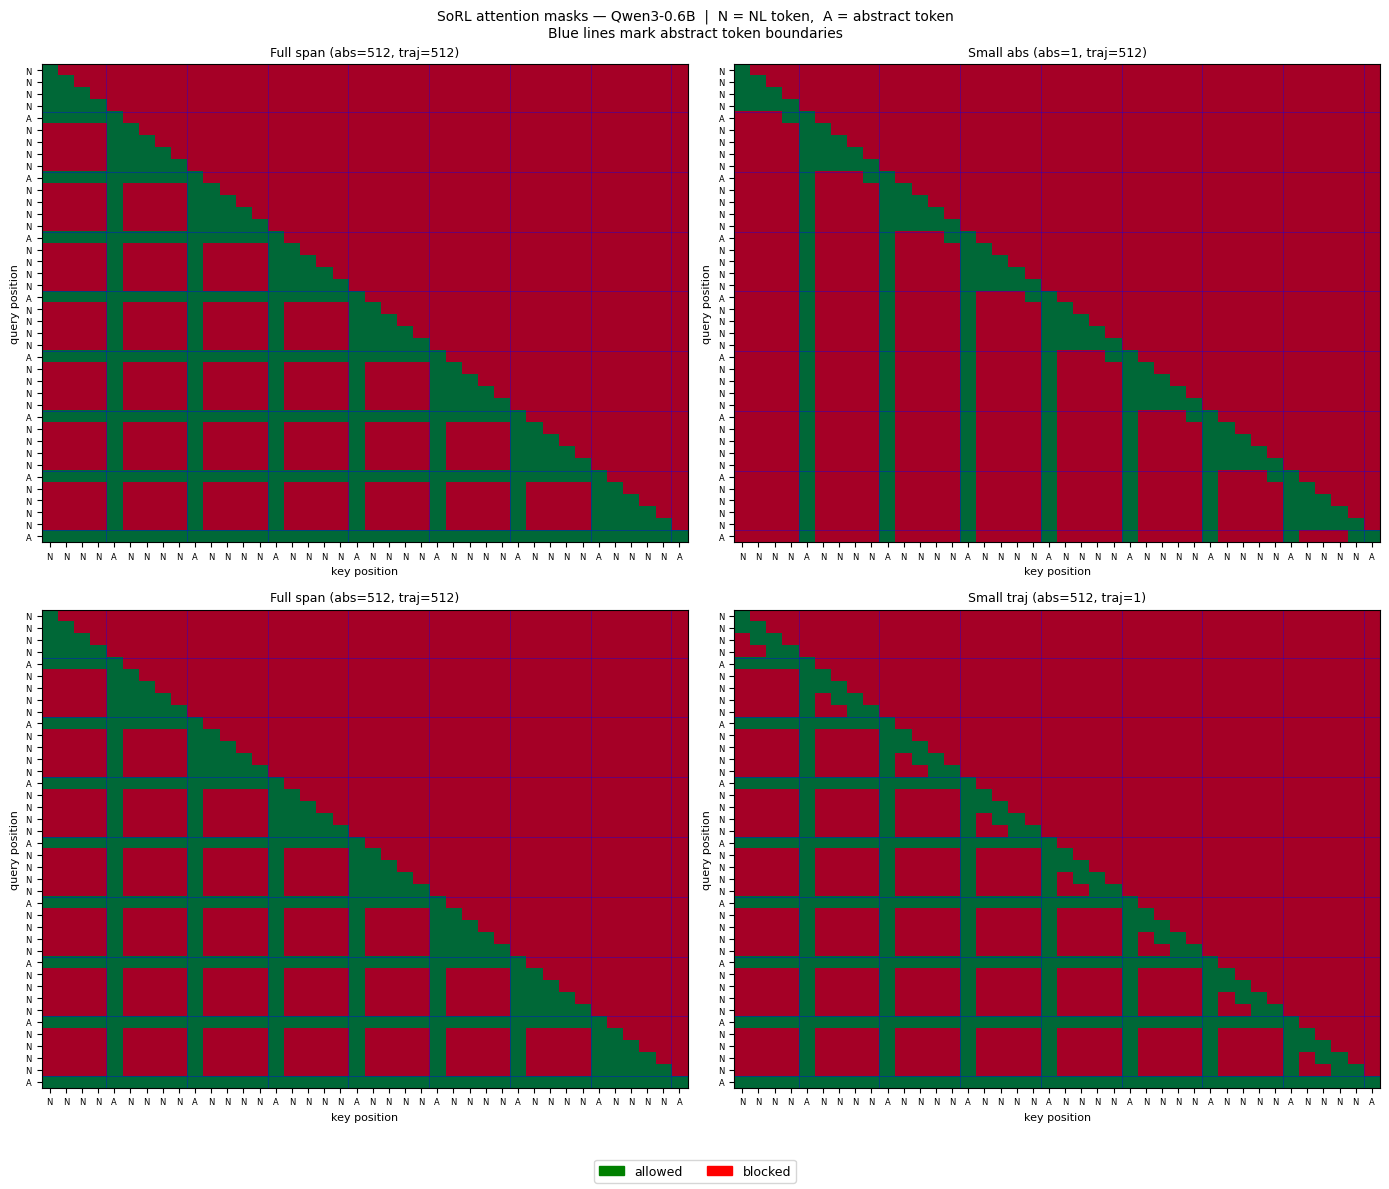

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_mask(ax, mask_tensor, token_ids, base_v, title):
    """Plot a single attention mask with N/A token annotations."""
    m = (mask_tensor[0, 0] == 0).cpu().numpy()   # True = allowed
    T = m.shape[0]
    labels = ['A' if t >= base_v else 'N' for t in token_ids]

    ax.imshow(m, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto', origin='upper')
    ax.set_xticks(range(T))
    ax.set_yticks(range(T))
    ax.set_xticklabels(labels, fontsize=6)
    ax.set_yticklabels(labels, fontsize=6)
    ax.set_xlabel('key position', fontsize=8)
    ax.set_ylabel('query position', fontsize=8)
    ax.set_title(title, fontsize=9)

    for i, lbl in enumerate(labels):
        if lbl == 'A':
            ax.axhline(y=i - 0.5, color='blue', linewidth=0.5, alpha=0.5)
            ax.axvline(x=i - 0.5, color='blue', linewidth=0.5, alpha=0.5)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
tok_list = q_tokens[0].tolist()

plot_mask(axes[0,0], q_mask_large_abs,  tok_list, qwen_base_vocab, 'Full span (abs=512, traj=512)')
plot_mask(axes[0,1], q_mask_small_abs,  tok_list, qwen_base_vocab, 'Small abs (abs=1, traj=512)')
plot_mask(axes[1,0], q_mask_large_traj, tok_list, qwen_base_vocab, 'Full span (abs=512, traj=512)')
plot_mask(axes[1,1], q_mask_small_traj, tok_list, qwen_base_vocab, 'Small traj (abs=512, traj=1)')

green = mpatches.Patch(color='green', label='allowed')
red   = mpatches.Patch(color='red',   label='blocked')
fig.legend(handles=[green, red], loc='lower center', ncol=2, fontsize=9)
fig.suptitle('SoRL attention masks — Qwen3-0.6B  |  N = NL token,  A = abstract token\nBlue lines mark abstract token boundaries', fontsize=10)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

In [21]:
from sorl.sorl_wrapper import infer_level

def check_mask_invariants(mask_tensor, token_ids_list, wrapper_ref, memory_span_abs, memory_span_traj, label):
    """
    Systematically verify the four SoRL gist rules on every (q, k) pair.
    """
    tok      = torch.tensor([token_ids_list])
    levels   = infer_level(tok, wrapper_ref.vocab_sizes)[0]      # (T,)
    acc      = levels.cumsum(0)                                   # (T,)
    att_mat  = (mask_tensor[0, 0] == 0).cpu()                    # (T, T) True=allowed
    T        = len(token_ids_list)

    fails = {r: [] for r in ['causal', 'nl_to_abs_always_open', 'abs_query_window', 'nl_nl_barrier']}

    for q in range(T):
        for k in range(T):
            att      = bool(att_mat[q, k].item())
            is_abs_q = bool(levels[q] > 0)
            is_abs_k = bool(levels[k] > 0)
            dist     = q - k

            # Rule 1: causal
            if k > q and att:
                fails['causal'].append((q, k))
            if k > q:
                continue

            # Rule 2: NL→ABS key must always be open (within global window 1792)
            if not is_abs_q and is_abs_k and dist < 1792:
                if not att:
                    fails['nl_to_abs_always_open'].append((q, k))

            # Rule 3: abstract query uses memory_span_abs window
            if is_abs_q:
                within = (dist <= memory_span_abs)
                if within and not att:
                    fails['abs_query_window'].append((f'q={q} k={k}', 'should be open'))
                if not within and att and not is_abs_k:
                    fails['abs_query_window'].append((f'q={q} k={k}', 'should be closed'))

            # Rule 4: NL→NL respects memory_span_traj and gist barrier (skip_abs)
            if not is_abs_q and not is_abs_k:
                skip            = bool(acc[q] > acc[k])
                within_traj     = (dist <= memory_span_traj)
                should_be_open  = within_traj and not skip
                if should_be_open and not att:
                    fails['nl_nl_barrier'].append((f'q={q} k={k}', 'should be open'))
                if not should_be_open and att:
                    fails['nl_nl_barrier'].append((f'q={q} k={k}', 'should be closed'))

    print(f"\n=== {label} ===")
    for rule, f in fails.items():
        status = '✓ PASS' if not f else f'✗ FAIL  ({len(f)} violations)'
        print(f"  {rule:30s}: {status}")
        if f:
            print(f"    first violations: {f[:5]}")
    return fails

tok_list = q_tokens[0].tolist()

check_mask_invariants(q_mask_large_abs,  tok_list, qwen_wrapper,
                      memory_span_abs=512, memory_span_traj=512, label='full span (abs=512, traj=512)')

check_mask_invariants(q_mask_small_abs,  tok_list, qwen_wrapper,
                      memory_span_abs=1,   memory_span_traj=512, label='small abs (abs=1, traj=512)')

check_mask_invariants(q_mask_small_traj, tok_list, qwen_wrapper,
                      memory_span_abs=512, memory_span_traj=1,   label='small traj (abs=512, traj=1)')


=== full span (abs=512, traj=512) ===
  causal                        : ✓ PASS
  nl_to_abs_always_open         : ✓ PASS
  abs_query_window              : ✓ PASS
  nl_nl_barrier                 : ✓ PASS

=== small abs (abs=1, traj=512) ===
  causal                        : ✓ PASS
  nl_to_abs_always_open         : ✓ PASS
  abs_query_window              : ✓ PASS
  nl_nl_barrier                 : ✓ PASS

=== small traj (abs=512, traj=1) ===
  causal                        : ✓ PASS
  nl_to_abs_always_open         : ✓ PASS
  abs_query_window              : ✓ PASS
  nl_nl_barrier                 : ✓ PASS


{'causal': [],
 'nl_to_abs_always_open': [],
 'abs_query_window': [],
 'nl_nl_barrier': []}